# Week 2: Dataset for Embedding  Evaluation & Embedding Comparison

This notebook implements the similarity pipeline and evaluates different embedding methods for the academic paper recommendation system.

**Tasks:**

1. Cross-Corpus Similarity (External ↔ BOUN)
2. Embedding Method Comparison (TF-IDF, Sentence Embeddings, Gemini API)
3. Intra-Paper Similarity (Same-Author & Cited Paper sanity checks)


In [1]:
import pandas as pd
import numpy as np
import json
import ast
import os
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
load_dotenv()

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from collections import defaultdict

pd.set_option('display.max_colwidth', 80)

GEMINI_API_KEY = 'XXXX'

## Load & Prepare Data


In [2]:
import pickle

PARSED_CACHE = "data/parsed_cache"
os.makedirs(PARSED_CACHE, exist_ok=True)

boun_cache = os.path.join(PARSED_CACHE, "boun_parsed.pkl")
followed_cache = os.path.join(PARSED_CACHE, "followed_parsed.pkl")

if os.path.exists(boun_cache) and os.path.exists(followed_cache):
    print("Loading pre-parsed data from cache...")
    with open(boun_cache, 'rb') as f:
        boun_data = pickle.load(f)
    with open(followed_cache, 'rb') as f:
        priority_followed_data = pickle.load(f)
else:
    boun_data = pd.read_csv("data/cleaned/boun.csv")
    priority_followed_data = pd.read_csv("data/cleaned/priority_followed.csv")

    def safe_parse(x):
        """Safely parse stringified JSON/lists using ast.literal_eval with fallback."""
        if pd.isna(x):
            return None
        if isinstance(x, str):
            x = x.strip()
            if x.startswith(('[{', '[', '{', '(')):
                try:
                    return ast.literal_eval(x)
                except (ValueError, SyntaxError):
                    try:
                        return json.loads(x)
                    except:
                        return x
        return x

    print("Parsing BOUN data...")
    for col in boun_data.columns:
        boun_data[col] = boun_data[col].map(safe_parse)

    print("Parsing priority_followed data...")
    for col in priority_followed_data.columns:
        priority_followed_data[col] = priority_followed_data[col].map(safe_parse)

    with open(boun_cache, 'wb') as f:
        pickle.dump(boun_data, f)
    with open(followed_cache, 'wb') as f:
        pickle.dump(priority_followed_data, f)
    print("Saved parsed data to cache.")

print(f"BOUN: {len(boun_data)} rows, Followed: {len(priority_followed_data)} rows")

Loading pre-parsed data from cache...


BOUN: 4608 rows, Followed: 9946 rows


In [3]:
print(f"BOUN papers: {len(boun_data)}")
print(f"Followed institution papers: {len(priority_followed_data)}")

# Filter to papers with abstracts (FULL corpus — used for Task 2 benchmark & Task 3)
boun_df_full = boun_data[boun_data['abstract'].notna() & (boun_data['abstract'].str.len() > 20)].reset_index(drop=True)
followed_df_full = priority_followed_data[priority_followed_data['abstract'].notna() & (priority_followed_data['abstract'].str.len() > 20)].reset_index(drop=True)

# Subsample for Task 1 (cross-corpus exploration) — keeps iteration fast
TASK1_CORPUS_SIZE = 500
boun_df = boun_df_full.sample(TASK1_CORPUS_SIZE, random_state=42).reset_index(drop=True)
followed_df = followed_df_full.sample(TASK1_CORPUS_SIZE, random_state=42).reset_index(drop=True)

print(f"\nFull corpus (for benchmark & sanity checks):")
print(f"  BOUN papers: {len(boun_df_full)}")
print(f"  Followed institution papers: {len(followed_df_full)}")
print(f"\nSubsampled (for Task 1 cross-corpus):")
print(f"  BOUN papers: {len(boun_df)}")
print(f"  Followed institution papers: {len(followed_df)}")

BOUN papers: 4608
Followed institution papers: 9946



Full corpus (for benchmark & sanity checks):
  BOUN papers: 3000
  Followed institution papers: 5851

Subsampled (for Task 1 cross-corpus):
  BOUN papers: 500
  Followed institution papers: 500


In [4]:
def extract_concept_names(val):
    """Extract concept display names from the concepts column."""
    if isinstance(val, list):
        return ' '.join(c.get('display_name', '') for c in val if isinstance(c, dict))
    return ''

def build_text(row, fields=('abstract', 'title', 'concepts')):
    """Build text representation from selected fields.
    
    Parameters
    ----------
    fields : tuple of str
        Any combination of 'abstract', 'title', 'concepts'. Default: all three.
    """
    parts = []
    if 'title' in fields and isinstance(row.get('title'), str) and row['title']:
        parts.append(row['title'])
    if 'abstract' in fields and isinstance(row.get('abstract'), str) and row['abstract']:
        parts.append(row['abstract'])
    if 'concepts' in fields:
        concept_text = extract_concept_names(row.get('concepts', ''))
        if concept_text.strip():
            parts.append(concept_text)
    return ' '.join(parts)

# Pre-build combined text for all dataframes
for df in [boun_df, followed_df, boun_df_full, followed_df_full]:
    df['text'] = df.apply(lambda r: build_text(r), axis=1)

In [5]:
print("Sample combined text:")
boun_df['text'].head()

Sample combined text:


0    Intertemporal and cross-sectional contrasts in effects of trade: Significanc...
1    Cyclic double punch test as a novel approach to reduce variation in concrete...
2    Modeling the Organizational Agility in the Architecture, Engineering, and Co...
3    Fling amplitude inventory of near-fault strong motion recordings in Turkiye ...
4    A Place under the Sun: Chinese Muslim (Hui) Identity and the Constitutional ...
Name: text, dtype: str

## Similarity Methods

Each method implements the same interface: given query texts and corpus texts, return a similarity matrix.


### Method 1: TF-IDF + Cosine Similarity


In [6]:
def tfidf_similarity(query_texts, corpus_texts):
    """Compute TF-IDF cosine similarity between query and corpus texts.
    
    Returns: np.ndarray of shape (len(query_texts), len(corpus_texts))
    """
    vectorizer = TfidfVectorizer(max_features=50000, stop_words='english')
    all_texts = list(corpus_texts) + list(query_texts)
    tfidf_matrix = vectorizer.fit_transform(all_texts)
    
    corpus_vectors = tfidf_matrix[:len(corpus_texts)]
    query_vectors = tfidf_matrix[len(corpus_texts):]
    
    return cosine_similarity(query_vectors, corpus_vectors)

### Method 1b: BM25 (Best Matching 25)

BM25 improves on TF-IDF by adding document length normalization and term frequency saturation via `k1` and `b` parameters. It is the strongest sparse retrieval baseline in information retrieval.

In [7]:
from rank_bm25 import BM25Okapi

def bm25_similarity(query_texts, corpus_texts):
    """Compute BM25 scores between query and corpus texts.
    
    Returns: np.ndarray of shape (len(query_texts), len(corpus_texts)),
             scores normalized to [0, 1] via saturation normalization.
    """
    tokenized_corpus = [doc.lower().split() for doc in corpus_texts]
    bm25 = BM25Okapi(tokenized_corpus)
    scores = np.array([bm25.get_scores(q.lower().split()) for q in query_texts])
    # Saturation normalization: score / (score + k), maps (0, ∞) → (0, 1)
    # k = median of positive scores keeps the curve centered
    positive = scores[scores > 0]
    k = float(np.median(positive)) if len(positive) > 0 else 1.0
    scores = np.where(scores > 0, scores / (scores + k), 0.0)
    return scores

print("BM25 method ready.")

BM25 method ready.


### Method 2: Sentence Embeddings (all-MiniLM-L6-v2 & SPECTER2)


In [8]:
import hashlib, os, time, torch

# Use MPS (Apple Silicon GPU) if available, else CPU
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Max token lengths per model (characters, rough estimate: 1 token ≈ 4 chars)
MAX_TEXT_CHARS = {
    'all-MiniLM-L6-v2': 1024,        # 256 tokens max
    'allenai/specter2_base': 2048,     # 512 tokens max
    'Qwen/Qwen3-Embedding-0.6B': 3200,  # ~800 tokens, model supports 8192 but memory-constrained
}

# Batch sizes tuned per model size (GPU-friendly)
BATCH_SIZES = {
    'all-MiniLM-L6-v2': 256,
    'allenai/specter2_base': 128,
    'Qwen/Qwen3-Embedding-0.6B': 64,  # larger batches OK on MPS/GPU
}

# Model cache to avoid reloading on every call
_MODEL_CACHE = {}

def _get_model(model_name):
    """Load a SentenceTransformer model, caching it for reuse."""
    if model_name not in _MODEL_CACHE:
        _MODEL_CACHE[model_name] = SentenceTransformer(model_name, trust_remote_code=True, device=DEVICE)
    return _MODEL_CACHE[model_name]

def _cache_path(model_name, prefix, n_texts, corpus_hash=""):
    """Generate a cache file path for embeddings."""
    safe_name = model_name.replace('/', '_').replace('-', '_')
    return f"data/embeddings_cache/{safe_name}_{prefix}_{n_texts}_{corpus_hash}.npy"

def _corpus_hash(texts):
    """Create a short hash from corpus texts to distinguish different corpora."""
    h = hashlib.md5("".join(texts[:5]).encode()).hexdigest()[:8]
    return h

def _truncate_texts(texts, model_name):
    """Truncate texts to max length for the given model."""
    max_chars = MAX_TEXT_CHARS.get(model_name, 2048)
    return [t[:max_chars] for t in texts]

def sentence_embedding_similarity(query_texts, corpus_texts, model_name='all-MiniLM-L6-v2', batch_size=None):
    """Compute cosine similarity using sentence transformer embeddings.
    Caches corpus embeddings to disk for reuse.
    
    Returns: np.ndarray of shape (len(query_texts), len(corpus_texts))
    """
    os.makedirs("data/embeddings_cache", exist_ok=True)
    
    if batch_size is None:
        batch_size = BATCH_SIZES.get(model_name, 64)
    
    # Truncate texts to avoid OOM on large models
    corpus_texts_enc = _truncate_texts(list(corpus_texts), model_name)
    query_texts_enc = _truncate_texts(list(query_texts), model_name)
    
    model = _get_model(model_name)
    
    c_hash = _corpus_hash(corpus_texts_enc)
    corpus_cache = _cache_path(model_name, "corpus", len(corpus_texts_enc), c_hash)
    if os.path.exists(corpus_cache):
        print(f"  Loading cached corpus embeddings from {corpus_cache}")
        corpus_embeddings = np.load(corpus_cache)
    else:
        print(f"  Encoding {len(corpus_texts_enc)} corpus texts with {model_name} (batch_size={batch_size})...")
        corpus_embeddings = model.encode(corpus_texts_enc, batch_size=batch_size, show_progress_bar=True)
        np.save(corpus_cache, corpus_embeddings)
        print(f"  Saved corpus embeddings to {corpus_cache}")
    
    print(f"  Encoding {len(query_texts_enc)} query texts...")
    query_embeddings = model.encode(query_texts_enc, batch_size=batch_size, show_progress_bar=True)
    
    return cosine_similarity(query_embeddings, corpus_embeddings)

print("Embedding methods ready: SentenceTransformer + Gemini Embedding")

Using device: mps
Embedding methods ready: SentenceTransformer + Gemini Embedding


### Method 3: Gemini API Similarity Scoring

Uses the Gemini API to directly score semantic similarity between paper pairs. Due to API rate limits, this is applied only to the top candidates pre-filtered by a fast method.


In [9]:
import google.generativeai as genai
import time
import os

if not GEMINI_API_KEY:
    print("⚠ GEMINI_API_KEY not set — Gemini methods will fail.")
else:
    genai.configure(api_key=GEMINI_API_KEY)
    print("Gemini API configured.")

def gemini_score_pair(query_text, candidate_text, model_name="gemini-3.1-flash-lite-preview"):
    """Use Gemini to score semantic similarity between two papers (0-100)."""
    prompt = f"""Rate the semantic similarity between these two academic papers on a scale of 0-100, 
where 0 means completely unrelated and 100 means nearly identical topics.

Paper A:
{query_text[:1500]}

Paper B:
{candidate_text[:1500]}

Respond with ONLY a single integer score (0-100), nothing else."""
    
    model = genai.GenerativeModel(model_name)
    try:
        response = model.generate_content(prompt)
        score = int(response.text.strip())
        return min(max(score, 0), 100) / 100.0
    except Exception as e:
        print(f"  Gemini error: {e}")
        return None

def gemini_rerank(query_text, candidate_texts, candidate_indices, top_k=3):
    """Re-rank top candidates using Gemini scoring.
    
    Returns list of (index, score) tuples sorted by Gemini score descending.
    """
    scored = []
    for idx, cand_text in zip(candidate_indices, candidate_texts):
        score = gemini_score_pair(query_text, cand_text)
        if score is not None:
            scored.append((idx, score))
        time.sleep(0.5)  # Rate limit
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:top_k]

Gemini API configured.


### Retrieval Helper

Generic function to retrieve top-K similar papers using any method.


In [10]:
MODEL_MAP = {
    'minilm': 'all-MiniLM-L6-v2',
    'specter2': 'allenai/specter2_base',
    'qwen': 'Qwen/Qwen3-Embedding-0.6B',
}

def reciprocal_rank_fusion(rankings_list, top_k=10, k=60):
    """Fuse multiple rankings using Reciprocal Rank Fusion (RRF).
    
    Parameters
    ----------
    rankings_list : list of list of (index, score)
    k : int — RRF constant (default 60)
    
    Returns: list of (index, rrf_score) sorted descending
    """
    rrf_scores = defaultdict(float)
    for rankings in rankings_list:
        for rank, (idx, _) in enumerate(rankings, 1):
            rrf_scores[idx] += 1.0 / (k + rank)
    sorted_results = sorted(rrf_scores.items(), key=lambda x: -x[1])
    return sorted_results[:top_k]

def retrieve_top_k(query_texts, corpus_texts, method, top_k=3, **kwargs):
    """Retrieve top-K similar corpus papers for each query.
    
    Parameters
    ----------
    method : str — 'tfidf', 'bm25', 'minilm', 'specter2', 'qwen', 'gemini_embed', 'gemini', or 'hybrid'
    Returns: list of list of (corpus_index, score)
    """
    if method == 'tfidf':
        sim_matrix = tfidf_similarity(query_texts, corpus_texts)
    elif method == 'bm25':
        sim_matrix = bm25_similarity(query_texts, corpus_texts)
    elif method in ('minilm', 'specter2', 'qwen'):
        sim_matrix = sentence_embedding_similarity(query_texts, corpus_texts, model_name=MODEL_MAP[method])
    elif method == 'gemini_embed':
        sim_matrix = gemini_embedding_similarity(query_texts, corpus_texts)
    elif method == 'gemini':
        pre_k = kwargs.get('pre_filter_k', 10)
        sim_matrix = tfidf_similarity(query_texts, corpus_texts)
        results = []
        for i in range(len(query_texts)):
            top_indices = np.argsort(sim_matrix[i])[::-1][:pre_k]
            cand_texts = [corpus_texts[j] for j in top_indices]
            reranked = gemini_rerank(query_texts[i], cand_texts, top_indices, top_k=top_k)
            results.append(reranked)
        return results
    elif method == 'hybrid':
        # Hybrid: BM25 + SPECTER2 fused via Reciprocal Rank Fusion
        pre_k = kwargs.get('pre_filter_k', 50)
        bm25_matrix = bm25_similarity(query_texts, corpus_texts)
        spec_matrix = sentence_embedding_similarity(query_texts, corpus_texts, model_name='allenai/specter2_base')
        results = []
        for i in range(len(query_texts)):
            bm25_top = np.argsort(bm25_matrix[i])[::-1][:pre_k]
            bm25_ranked = [(idx, bm25_matrix[i, idx]) for idx in bm25_top]
            spec_top = np.argsort(spec_matrix[i])[::-1][:pre_k]
            spec_ranked = [(idx, spec_matrix[i, idx]) for idx in spec_top]
            fused = reciprocal_rank_fusion([bm25_ranked, spec_ranked], top_k=top_k)
            results.append(fused)
        return results
    else:
        raise ValueError(f"Unknown method: {method}")
    
    results = []
    for i in range(sim_matrix.shape[0]):
        top_indices = np.argsort(sim_matrix[i])[::-1][:top_k]
        results.append([(idx, sim_matrix[i, idx]) for idx in top_indices])
    return results

print("retrieve_top_k() ready — supports: tfidf, bm25, minilm, specter2, qwen, gemini_embed, gemini, hybrid")

retrieve_top_k() ready — supports: tfidf, bm25, minilm, specter2, qwen, gemini_embed, gemini, hybrid


## Task 1 — Cross-Corpus Similarity

**1a.** 50 followed-institution papers → top-3 similar BOUN papers  
**1b.** 50 BOUN papers → top-3 similar followed-institution papers

In [11]:
import pickle

CACHE_DIR = "data/results_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

np.random.seed(42)
sample_followed = followed_df.sample(50).reset_index(drop=True)
sample_boun = boun_df.sample(50).reset_index(drop=True)

METHODS = ['tfidf', 'bm25', 'minilm', 'specter2', 'hybrid'] # qwen, gemini_embed, gemini
method_labels = {
    'tfidf': 'TF-IDF', 'bm25': 'BM25', 'minilm': 'MiniLM', 'specter2': 'SPECTER2',
    'qwen': 'Qwen3-Emb', 'gemini_embed': 'Gemini Embed', 'gemini': 'Gemini',
    'hybrid': 'Hybrid (BM25+SPECTER2)'
}
colors = {
    'tfidf': '#e74c3c', 'bm25': '#f39c12', 'minilm': '#3498db', 'specter2': '#2ecc71',
    'qwen': '#8e44ad', 'gemini_embed': '#9b59b6', 'gemini': '#e67e22', 'hybrid': '#1abc9c'
}

# --- Task 1a: External → BOUN ---
cache_1a = os.path.join(CACHE_DIR, "results_1a.pkl")

if os.path.exists(cache_1a):
    print(f"Loading cached Task 1a results from {cache_1a}")
    with open(cache_1a, 'rb') as f:
        results_1a = pickle.load(f)
    # Check if all methods are cached, compute missing ones
    missing = [m for m in METHODS if m not in results_1a]
    if missing:
        print(f"  Computing missing methods: {missing}")
        for method in missing:
            print(f"  ▶ Running {method}...")
            results_1a[method] = retrieve_top_k(
                list(sample_followed['text']), list(boun_df['text']),
                method=method, top_k=3
            )
        with open(cache_1a, 'wb') as f:
            pickle.dump(results_1a, f)
        print(f"  Updated cache with new methods")
else:
    print("=" * 80)
    print("TASK 1a: External → BOUN (50 followed-institution queries → BOUN corpus)")
    print("=" * 80)

    results_1a = {}
    for method in METHODS:
        print(f"\n▶ Running {method}...")
        results_1a[method] = retrieve_top_k(
            list(sample_followed['text']),
            list(boun_df['text']),
            method=method,
            top_k=3
        )
    with open(cache_1a, 'wb') as f:
        pickle.dump(results_1a, f)
    print(f"\nSaved Task 1a results to {cache_1a}")

# Display side-by-side comparison for first 3 queries
for i in range(3):
    query_title = str(sample_followed.iloc[i]['title'])[:80]
    print(f"\n{'─'*80}")
    print(f"Query {i+1}: {query_title}")
    for method in METHODS:
        hits = results_1a[method][i]
        print(f"  [{method_labels[method]:>20}]")
        for rank, (idx, score) in enumerate(hits, 1):
            match_title = str(boun_df.iloc[idx]['title'])[:60]
            print(f"    #{rank} ({score:.3f}) {match_title}")

Loading cached Task 1a results from data/results_cache/results_1a.pkl
  Computing missing methods: ['bm25', 'hybrid']
  ▶ Running bm25...


  ▶ Running hybrid...


No sentence-transformers model found with name allenai/specter2_base. Creating a new one with mean pooling.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 36241.00it/s]

...

  Loading cached corpus embeddings from data/embeddings_cache/allenai_specter2_base_corpus_500_ac4010d4.npy
  Encoding 50 query texts...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:03<00:00,  3.62s/it]

Batches: 100%|██████████| 1/1 [00:03<00:00,  3.65s/it]

  Updated cache with new methods

────────────────────────────────────────────────────────────────────────────────
Query 1: Can N95 Respirators Be Reused after Disinfection? How Many Times?
  [              TF-IDF]
    #1 (0.110) The Buffering Effects of Social Insurance for the Spread of 
    #2 (0.092) Fiscal stimulus packages to COVID‐19: The role of informalit
    #3 (0.069) Evaluation of Knowledge, Behavior, and Attitudes of Construc
  [                BM25]
    #1 (0.693) Evaluation of Knowledge, Behavior, and Attitudes of Construc
    #2 (0.664) The Buffering Effects of Social Insurance for the Spread of 
    #3 (0.651) Screening of Clinically Approved and Investigation Drugs as 
  [              MiniLM]
    #1 (0.273) Numerical Optimization of Gas Cooler Geometry in Transcritic
    #2 (0.271) Scalable Yielding of Highly Stable Polyelectrolyte‐Coated Co
    #3 (0.268) Microfluidic contact lenses for ocular diagnostics and drug 
  [            SPECTER2]
    #1 (0.893) Microfluidi

In [12]:
# --- Task 1b: BOUN → External ---
cache_1b = os.path.join(CACHE_DIR, "results_1b.pkl")

if os.path.exists(cache_1b):
    print(f"Loading cached Task 1b results from {cache_1b}")
    with open(cache_1b, 'rb') as f:
        results_1b = pickle.load(f)
    missing = [m for m in METHODS if m not in results_1b]
    if missing:
        print(f"  Computing missing methods: {missing}")
        for method in missing:
            print(f"  ▶ Running {method}...")
            results_1b[method] = retrieve_top_k(
                list(sample_boun['text']), list(followed_df['text']),
                method=method, top_k=3
            )
        with open(cache_1b, 'wb') as f:
            pickle.dump(results_1b, f)
        print(f"  Updated cache with new methods")
else:
    print("=" * 80)
    print("TASK 1b: BOUN → External (50 BOUN queries → followed-institution corpus)")
    print("=" * 80)

    results_1b = {}
    for method in METHODS:
        print(f"\n▶ Running {method}...")
        results_1b[method] = retrieve_top_k(
            list(sample_boun['text']),
            list(followed_df['text']),
            method=method,
            top_k=3
        )
    with open(cache_1b, 'wb') as f:
        pickle.dump(results_1b, f)
    print(f"\nSaved Task 1b results to {cache_1b}")

# Display side-by-side comparison for first 3 queries
for i in range(3):
    query_title = str(sample_boun.iloc[i]['title'])[:80]
    print(f"\n{'─'*80}")
    print(f"Query {i+1}: {query_title}")
    for method in METHODS:
        hits = results_1b[method][i]
        print(f"  [{method_labels[method]:>20}]")
        for rank, (idx, score) in enumerate(hits, 1):
            match_title = str(followed_df.iloc[idx]['title'])[:60]
            print(f"    #{rank} ({score:.3f}) {match_title}")

Loading cached Task 1b results from data/results_cache/results_1b.pkl
  Computing missing methods: ['bm25', 'hybrid']
  ▶ Running bm25...


  ▶ Running hybrid...


  Loading cached corpus embeddings from data/embeddings_cache/allenai_specter2_base_corpus_500_4ffe20f9.npy
  Encoding 50 query texts...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:02<00:00,  2.62s/it]

Batches: 100%|██████████| 1/1 [00:02<00:00,  2.62s/it]

  Updated cache with new methods

────────────────────────────────────────────────────────────────────────────────
Query 1: A local earthquake tomography on the EAF shows dipping fault structure
  [              TF-IDF]
    #1 (0.078) Urban Seismic Site Characterization by Fiber‐Optic Seismolog
    #2 (0.063) A Phase 2/3 Prospective Multicenter Study of the Diagnostic 
    #3 (0.060) Relativistic kinematics of a magnetic soliton
  [                BM25]
    #1 (0.674) Relativistic kinematics of a magnetic soliton
    #2 (0.672) DeepMIP: model intercomparison of early Eocene climatic opti
    #3 (0.672) UNETR++: Delving Into Efficient and Accurate 3D Medical Imag
  [              MiniLM]
    #1 (0.359) Urban Seismic Site Characterization by Fiber‐Optic Seismolog
    #2 (0.261) <i>Gaia</i>Early Data Release 3
    #3 (0.219) First Sagittarius A* Event Horizon Telescope Results. IV. Va
  [            SPECTER2]
    #1 (0.857) Urban Seismic Site Characterization by Fiber‐Optic Seismolog
    

In [13]:
# --- Task 1a: Compact Top-1 comparison table ---
rows = []
for i in range(len(sample_followed)):
    row = {'Query Paper': str(sample_followed.iloc[i]['title'])}
    for method in METHODS:
        idx, score = results_1a[method][i][0]
        title = str(boun_df.iloc[idx]['title'])
        pct = int(round(score * 100))
        row[f'{method_labels[method]} #1'] = f"[{pct}%] - {title}"
    rows.append(row)

df_1a_top1 = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 80)
print(f"Task 1a — External → BOUN: Top-1 per method ({len(df_1a_top1)} queries)")
df_1a_top1

Task 1a — External → BOUN: Top-1 per method (50 queries)


,Query Paper,TF-IDF #1,BM25 #1,MiniLM #1,SPECTER2 #1,Hybrid (BM25+SPECTER2) #1
0,Can N95 Respirators Be Reused after Disinfection? How Many Times?,[11%] - The Buffering Effects of Social Insurance for the Spread of Covid-19,"[69%] - Evaluation of Knowledge, Behavior, and Attitudes of Construction Wor...",[27%] - Numerical Optimization of Gas Cooler Geometry in Transcritical Refri...,[89%] - Microfluidic contact lenses for ocular diagnostics and drug delivery,"[3%] - Evaluation of Knowledge, Behavior, and Attitudes of Construction Work..."
1,The clustering of DESI-like luminous red galaxies using photometric redshifts,[12%] - Analysis of clustering and degree index in random graphs and complex...,[65%] - The NANOGrav 12.5 yr Data Set: A Computationally Efficient Eccentric...,[37%] - The Dark Universe Is Not Invisible,[84%] - Operation and performance of the ATLAS semiconductor tracker in LHC ...,[3%] - Clustering Event Streams With Low Rank Hawkes Processes
2,Structure of the lysosomal mTORC1–TFEB–Rag–Ragulator megacomplex,[7%] - Evaluating GPT and BERT models for protein–protein interaction identi...,[69%] - Distinct interaction modes orchestrate the polymerization of <scp>AS...,[35%] - Time-dependent re-organization of biological processes by the analys...,"[83%] - Computational analysis of missense filamin-A variants, including the...",[3%] - Leading quantum correction to the classical free energy
3,The Human Phenotype Ontology in 2024: phenotypes around the world,[6%] - The Complex Genetic Landscape of Hereditary Ataxias in Turkey and Imp...,[63%] - Artificial Intelligence in Cancer: A SWOT Analysis,[44%] - Cluster-based mention typing for named entity disambiguation,[90%] - Artificial Intelligence in Cancer: A SWOT Analysis,[3%] - Artificial Intelligence in Cancer: A SWOT Analysis
4,The primary mechanism of cytotoxicity of the chemotherapeutic agent CX-5461 ...,[14%] - Time-dependent re-organization of biological processes by the analys...,[68%] - Time-dependent re-organization of biological processes by the analys...,[45%] - Time-dependent re-organization of biological processes by the analys...,[93%] - Artificial Intelligence in Cancer: A SWOT Analysis,[3%] - Label‐Free Identification of Exosomes using Raman Spectroscopy and Ma...
5,National Response to COVID-19 in the Republic of Korea and Lessons Learned f...,[26%] - The Buffering Effects of Social Insurance for the Spread of Covid-19,[74%] - The Buffering Effects of Social Insurance for the Spread of Covid-19,[49%] - The Buffering Effects of Social Insurance for the Spread of Covid-19,[91%] - The Buffering Effects of Social Insurance for the Spread of Covid-19,[3%] - The Buffering Effects of Social Insurance for the Spread of Covid-19
6,UNETR++: Delving Into Efficient and Accurate 3D Medical Image Segmentation,[26%] - On the Use of a Convolutional Block Attention Module in Deep Learnin...,[72%] - FPGA implementation of double-head SalsaNext: a CNN-based model for ...,[44%] - ISNAS-DIP: Image-Specific Neural Architecture Search for Deep Image ...,[91%] - Edge-Compatible Deep Learning for Biometric Identification from Wris...,[3%] - MIDISpace: Finding Linear Directions in Latent Space for Music Genera...
7,"Head and Neck Cancers, Version 2.2020, NCCN Clinical Practice Guidelines in ...",[11%] - FPGA implementation of double-head SalsaNext: a CNN-based model for ...,[51%] - Cholesterol biogenesis is a PTEN‐dependent actionable node for the t...,[32%] - Artificial Intelligence in Cancer: A SWOT Analysis,[89%] - Artificial Intelligence in Cancer: A SWOT Analysis,[3%] - Artificial Intelligence in Cancer: A SWOT Analysis
8,Rapid implementation of mobile technology for real-time epidemiology of COVI...,[27%] - The Buffering Effects of Social Insurance for the Spread of Covid-19,[69%] - Screening of Clinically Approved and Investigation Drugs as Potentia...,[46%] - The Buffering Effects of Social Insurance for the Spread of Covid-19,[92%] - The Buffering Effects of Social Insu

In [14]:
# --- Task 1b: Compact Top-1 comparison table ---
rows = []
for i in range(len(sample_boun)):
    row = {'Query Paper': str(sample_boun.iloc[i]['title'])}
    for method in METHODS:
        idx, score = results_1b[method][i][0]
        title = str(followed_df.iloc[idx]['title'])
        pct = int(round(score * 100))
        row[f'{method_labels[method]} #1'] = f"[{pct}%] - {title}"
    rows.append(row)

df_1b_top1 = pd.DataFrame(rows)
print(f"Task 1b — BOUN → External: Top-1 per method ({len(df_1b_top1)} queries)")
df_1b_top1

Task 1b — BOUN → External: Top-1 per method (50 queries)


,Query Paper,TF-IDF #1,BM25 #1,MiniLM #1,SPECTER2 #1,Hybrid (BM25+SPECTER2) #1
0,A local earthquake tomography on the EAF shows dipping fault structure,[8%] - Urban Seismic Site Characterization by Fiber‐Optic Seismology,[67%] - Relativistic kinematics of a magnetic soliton,[36%] - Urban Seismic Site Characterization by Fiber‐Optic Seismology,[86%] - Urban Seismic Site Characterization by Fiber‐Optic Seismology,[3%] - Urban Seismic Site Characterization by Fiber‐Optic Seismology
1,The effect of business administration students’ individual values on their e...,"[24%] - Context, time, and change: Historical approaches to entrepreneurship...","[60%] - Context, time, and change: Historical approaches to entrepreneurship...","[40%] - Context, time, and change: Historical approaches to entrepreneurship...",[88%] - Understanding inclusion in collaborative governance: a mixed methods...,"[3%] - Context, time, and change: Historical approaches to entrepreneurship ..."
2,Pre-Service Mathematics and Physics Teachers’ Experiences of Implementing Pe...,[19%] - A CHecklist for statistical Assessment of Medical Papers (the CHAMP ...,[59%] - A CHecklist for statistical Assessment of Medical Papers (the CHAMP ...,[25%] - A CHecklist for statistical Assessment of Medical Papers (the CHAMP ...,[89%] - A CHecklist for statistical Assessment of Medical Papers (the CHAMP ...,[3%] - A CHecklist for statistical Assessment of Medical Papers (the CHAMP s...
3,Equivalence of matter-type modified gravity theories to general relativity w...,[41%] - Dark Energy Survey Year 3 results: Cosmology from cosmic shear and r...,[64%] - On the Evolution of the Hubble Constant with the SNe Ia Pantheon Sam...,[33%] - Statistical localization: From strong fragmentation to strong edge m...,[91%] - Statistical localization: From strong fragmentation to strong edge m...,[3%] - Large-misalignment mechanism for the formation of compact axion struc...
4,TRIFIN: Hybrid Indoor Positioning with Bluetooth Internet of Things Gateways,[12%] - A Survey on Computational Propaganda Detection,[53%] - Hardware Implementation of Deep Network Accelerators Towards Healthc...,[20%] - Multi-task deep learning for cardiac rhythm detection in wearable de...,[86%] - Multi‐Parameter Optimized Triboelectric Nanogenerator Based Self‐Pow...,[3%] - Multi‐Parameter Optimized Triboelectric Nanogenerator Based Self‐Powe...
5,Excitons in strained and suspended monolayer WSe <sub>2</sub>,[15%] - Extreme tensile strain states in La <sub>0.7</sub> Ca <sub>0.3</sub>...,[69%] - <i>Planck</i> 2018 results,[38%] - Single-Atom Pt Anchored on Oxygen Vacancy of Monolayer Ti<sub>3</sub...,[88%] - Extreme tensile strain states in La <sub>0.7</sub> Ca <sub>0.3</sub>...,[3%] - Extreme tensile strain states in La <sub>0.7</sub> Ca <sub>0.3</sub> ...
6,A new formulation for a code‐based vertical design spectrum,[11%] - Subambient daytime radiative cooling of vertical surfaces,[69%] - Improved SMAP Dual-Channel Algorithm for the Retrieval of Soil Moisture,[47%] - Urban Seismic Site Characterization by Fiber‐Optic Seismology,[89%] - Seawater sea-sand engineered/strain-hardening cementitious composite...,[3%] - Improved SMAP Dual-Channel Algorithm for the Retrieval of Soil Moisture
7,The effects of dihedral angle on hover rigidity and planar maneuvers in rota...,[5%] - MobileNeRF: Exploiting the Polygon Rasterization Pipeline for Efficie...,[68%] - Frequency-Dependent Squeezing for Advanced LIGO,[36%] - FASTER: Fast and Safe Trajectory Planner for Navigation in Unknown E...,[87%] - FASTER: Fast and Safe Trajectory Planner for Navigation in Unknown E...,[3%] - FASTER: Fast and Safe Trajectory Planner for Navigation in Unknown En...
8,Boundary effects on the thermodynamics of quantum fields near a static black...,[16%] - First Sagittarius A* Event Horizon Telescope Results. IV. Variabilit...,[73%] - First Sagittarius A* Event Horizon Telescope Results. IV. Variabilit...,[34%] - Conservative Dynamics of Binary Systems to T

## Task 2 — Embedding Method Comparison

Evaluate all methods against the **benchmark pairs** from Week 1.  
**Metrics:** Hit Rate@K (fraction of queries where ≥1 positive is in top-K), Mean Reciprocal Rank (MRR).


In [15]:
# Load benchmark pairs
with open('eval_dataset/benchmark_pairs_with_related_works.json') as f:
    benchmark_pairs = json.load(f)

print(f"Loaded {len(benchmark_pairs)} benchmark query-positive pairs")

# Build lookup: BOUN paper id → index in boun_df_full (FULL corpus, not subsampled)
boun_id_to_idx = {str(row['id']): i for i, row in boun_df_full.iterrows()}

# Build query texts and collect expected positive BOUN paper ids
bench_queries = []
bench_positive_ids = []

for pair in benchmark_pairs:
    query = pair['query']
    q_text = f"{query.get('title', '')} {query.get('abstract', '')}"
    bench_queries.append(q_text)
    bench_positive_ids.append([p['id'] for p in pair['positives']])

# Check how many positives are actually in the corpus
total_positives = sum(len(p) for p in bench_positive_ids)
found_positives = sum(
    sum(1 for pid in pids if str(pid) in boun_id_to_idx)
    for pids in bench_positive_ids
)

print(f"Benchmark queries: {len(bench_queries)}")
print(f"Avg positives per query: {np.mean([len(p) for p in bench_positive_ids]):.1f}")
print(f"Positive coverage in full corpus: {found_positives}/{total_positives} ({found_positives/total_positives*100:.1f}%)")

Loaded 100 benchmark query-positive pairs


Benchmark queries: 100
Avg positives per query: 2.0
Positive coverage in full corpus: 198/198 (100.0%)


In [16]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

# --- Evaluate benchmark: Hit Rate@K, MRR, NDCG@K, MAP@K ---
K_VALUES = [1, 3, 5, 10]

def average_precision_at_k(retrieved_ids, positive_id_set, k):
    """Compute Average Precision at K for a single query."""
    hits = 0
    sum_precisions = 0.0
    for i, rid in enumerate(retrieved_ids[:k], 1):
        if rid in positive_id_set:
            hits += 1
            sum_precisions += hits / i
    return sum_precisions / min(len(positive_id_set), k) if positive_id_set else 0.0

def ndcg_at_k(retrieved_ids, positive_id_set, k):
    """Compute NDCG at K for a single query (binary relevance)."""
    dcg = 0.0
    for i, rid in enumerate(retrieved_ids[:k]):
        if rid in positive_id_set:
            dcg += 1.0 / np.log2(i + 2)  # i+2 because rank starts at 1
    # Ideal DCG: all relevant docs at top
    n_relevant = min(len(positive_id_set), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(n_relevant))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_method(method_name, bench_queries, bench_positive_ids, corpus_texts, corpus_df, k_values=K_VALUES):
    """Evaluate a retrieval method on benchmark pairs.
    Returns dict with Hit Rate@K, MRR, NDCG@K, MAP@K, and per-query reciprocal ranks.
    """
    results = retrieve_top_k(bench_queries, corpus_texts, method=method_name, top_k=max(k_values))
    
    hit_rates = {k: 0 for k in k_values}
    reciprocal_ranks = []
    ndcg_scores = {k: [] for k in k_values}
    map_scores = {k: [] for k in k_values}
    
    for i, (top_hits, pos_ids) in enumerate(zip(results, bench_positive_ids)):
        pos_id_set = set(str(pid) for pid in pos_ids)
        retrieved_ids = [str(corpus_df.iloc[idx]['id']) for idx, score in top_hits]
        
        # MRR: rank of first relevant hit
        rr = 0.0
        for rank, rid in enumerate(retrieved_ids, 1):
            if rid in pos_id_set:
                rr = 1.0 / rank
                break
        reciprocal_ranks.append(rr)
        
        # Hit Rate@K, NDCG@K, MAP@K
        for k in k_values:
            top_k_ids = set(retrieved_ids[:k])
            if top_k_ids & pos_id_set:
                hit_rates[k] += 1
            ndcg_scores[k].append(ndcg_at_k(retrieved_ids, pos_id_set, k))
            map_scores[k].append(average_precision_at_k(retrieved_ids, pos_id_set, k))
    
    n = len(bench_queries)
    return {
        'hit_rate': {k: hit_rates[k] / n for k in k_values},
        'mrr': float(np.mean(reciprocal_ranks)),
        'ndcg': {k: float(np.mean(ndcg_scores[k])) for k in k_values},
        'map': {k: float(np.mean(map_scores[k])) for k in k_values},
        'reciprocal_ranks': [float(r) for r in reciprocal_ranks]
    }

# Run evaluation on FULL corpus (with caching)
cache_eval = os.path.join(CACHE_DIR, "eval_results_full.pkl")

if os.path.exists(cache_eval):
    print(f"Loading cached eval results from {cache_eval}")
    with open(cache_eval, 'rb') as f:
        eval_results = pickle.load(f)
    missing = [m for m in METHODS if m not in eval_results]
    if missing:
        print(f"  Computing missing methods: {missing}")
        for method in missing:
            print(f"Evaluating {method} on full corpus ({len(boun_df_full)} papers)...")
            eval_results[method] = evaluate_method(method, bench_queries, bench_positive_ids,
                                                    list(boun_df_full['text']), boun_df_full)
        with open(cache_eval, 'wb') as f:
            pickle.dump(eval_results, f)
else:
    eval_results = {}
    for method in METHODS:
        print(f"Evaluating {method} on full corpus ({len(boun_df_full)} papers)...")
        eval_results[method] = evaluate_method(method, bench_queries, bench_positive_ids,
                                                list(boun_df_full['text']), boun_df_full)
    with open(cache_eval, 'wb') as f:
        pickle.dump(eval_results, f)
    print(f"\nSaved eval results to {cache_eval}")

# Print summary table
header = f"{'Method':<20} {'MRR':>6}  " + "  ".join(f"HR@{k}" for k in K_VALUES) + "  " + "  ".join(f"NDCG@{k}" for k in K_VALUES) + "  " + "  ".join(f"MAP@{k}" for k in K_VALUES)
print(f"\n{header}")
print("─" * len(header))
for method in METHODS:
    r = eval_results[method]
    hr_str = "  ".join(f"{r['hit_rate'][k]:5.3f}" for k in K_VALUES)
    ndcg_str = "  ".join(f"{r['ndcg'][k]:6.3f}" for k in K_VALUES)
    map_str = "  ".join(f"{r['map'][k]:5.3f}" for k in K_VALUES)
    print(f"{method_labels[method]:<20} {r['mrr']:>6.3f}  {hr_str}  {ndcg_str}  {map_str}")

Loading cached eval results from data/results_cache/eval_results_full.pkl
  Computing missing methods: ['bm25', 'hybrid']
Evaluating bm25 on full corpus (3000 papers)...


Evaluating hybrid on full corpus (3000 papers)...


  Loading cached corpus embeddings from data/embeddings_cache/allenai_specter2_base_corpus_3000_cf1bc745.npy
  Encoding 100 query texts...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [07:56<00:00, 476.43s/it]

Batches: 100%|██████████| 1/1 [07:56<00:00, 476.51s/it]


Method                  MRR  HR@1  HR@3  HR@5  HR@10  NDCG@1  NDCG@3  NDCG@5  NDCG@10  MAP@1  MAP@3  MAP@5  MAP@10
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
TF-IDF                0.248  0.130  0.300  0.390  0.540   0.130   0.161   0.192   0.239  0.130  0.128  0.145  0.167
BM25                  0.203  0.090  0.280  0.360  0.480   0.090   0.128   0.157   0.196  0.090  0.092  0.109  0.126
MiniLM                0.313  0.190  0.360  0.460  0.660   0.190   0.194   0.234   0.286  0.190  0.152  0.177  0.199
SPECTER2              0.276  0.170  0.320  0.420  0.560   0.170   0.166   0.197   0.239  0.170  0.128  0.144  0.164
Hybrid (BM25+SPECTER2)  0.296  0.210  0.300  0.420  0.550   0.210   0.179   0.214   0.253  0.210  0.146  0.164  0.181


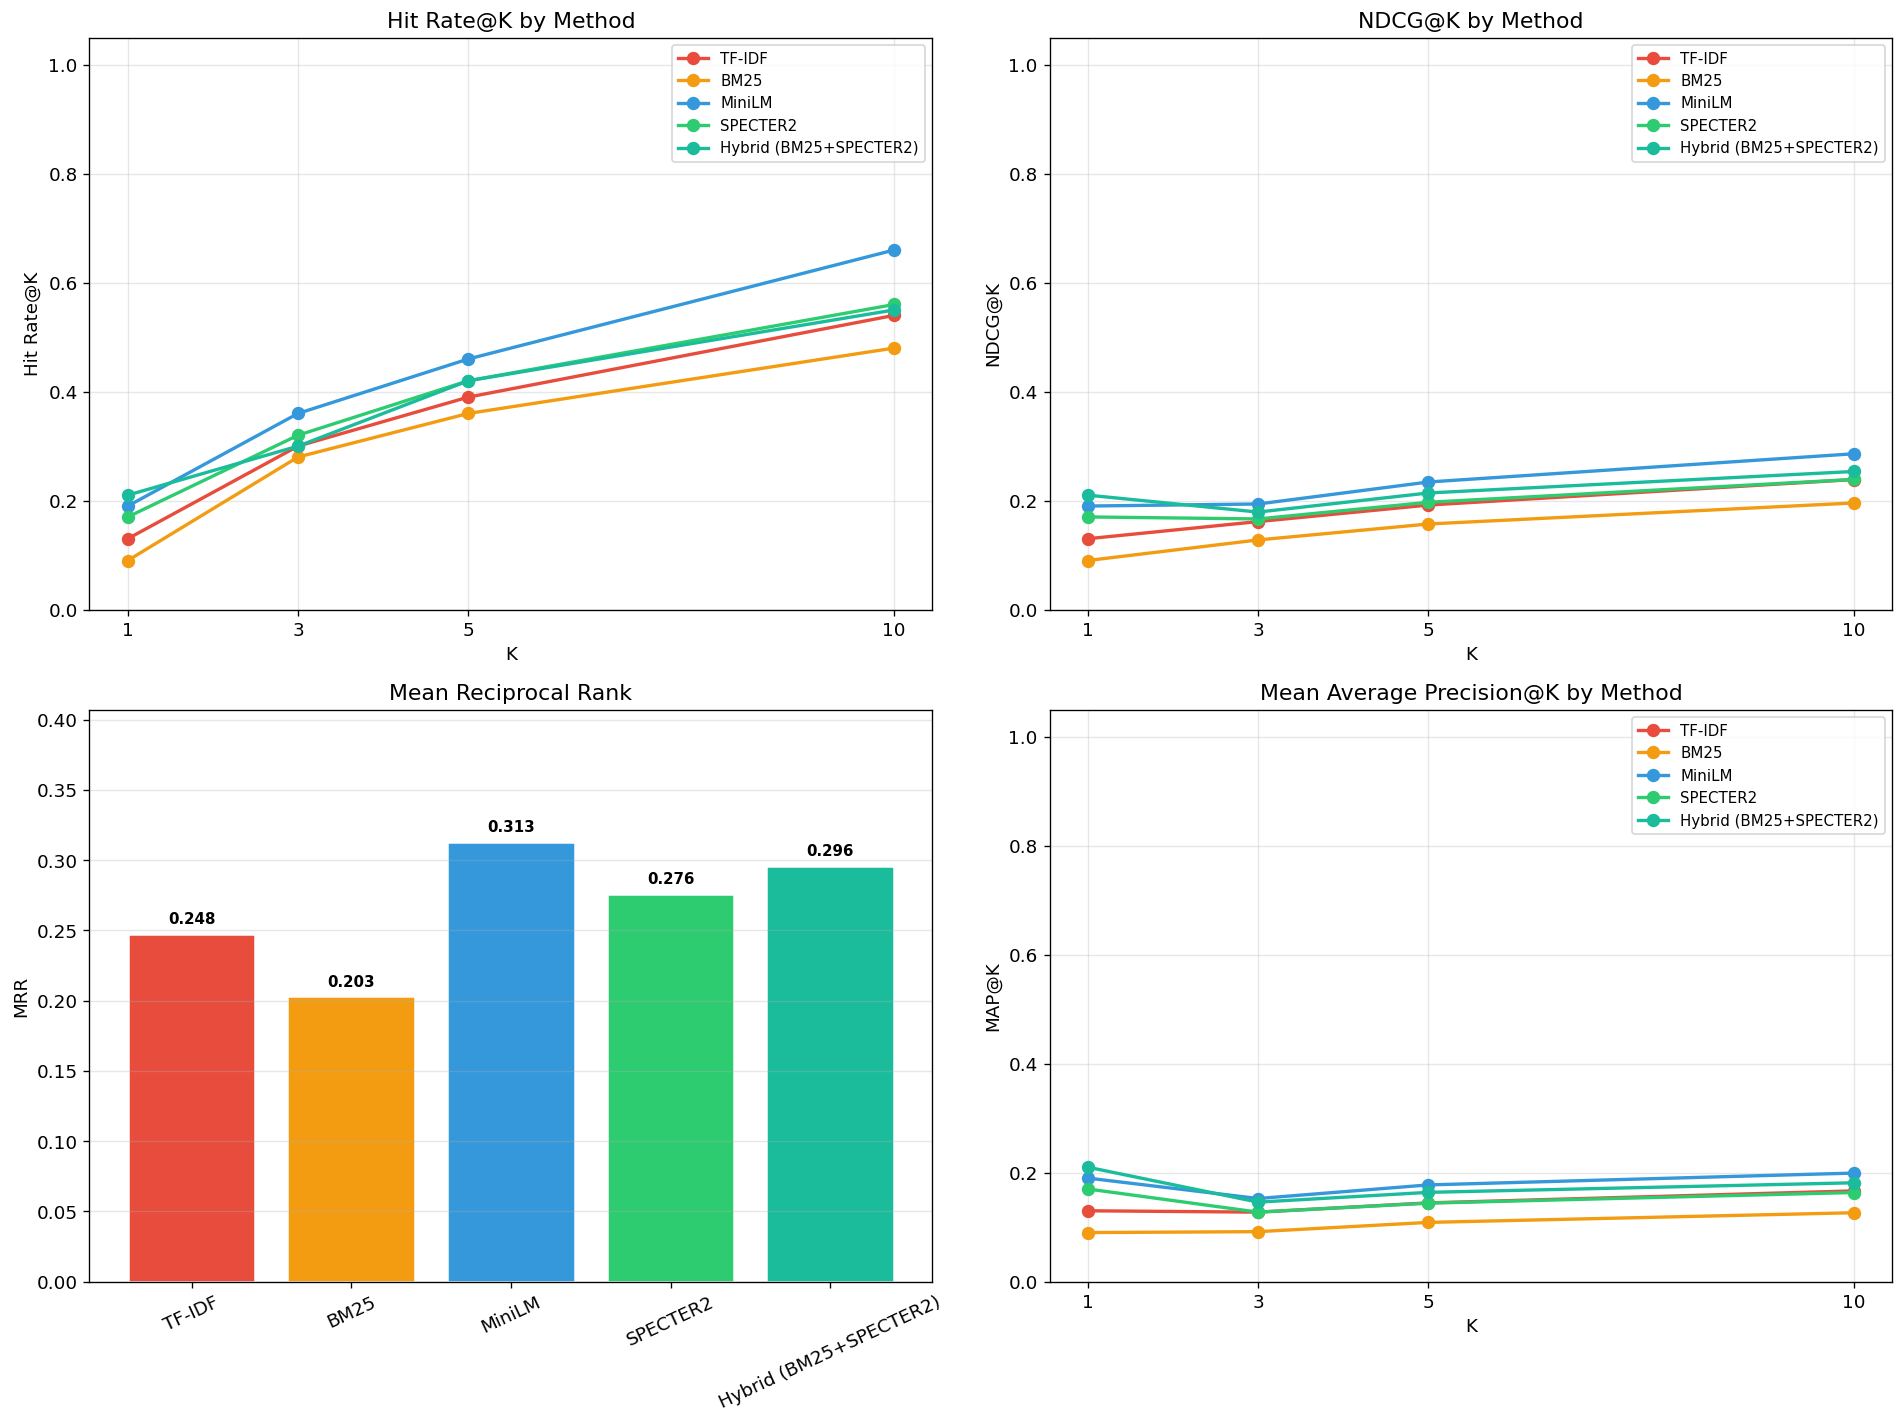

Saved: eval_dataset/embedding_comparison.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Hit Rate@K ---
ax = axes[0, 0]
for method in METHODS:
    hr = eval_results[method]['hit_rate']
    ax.plot(K_VALUES, [hr[k] for k in K_VALUES], 'o-', color=colors[method],
            label=method_labels[method], linewidth=2, markersize=7)
ax.set_xlabel('K')
ax.set_ylabel('Hit Rate@K')
ax.set_title('Hit Rate@K by Method')
ax.set_xticks(K_VALUES)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 2: NDCG@K ---
ax = axes[0, 1]
for method in METHODS:
    ndcg = eval_results[method]['ndcg']
    ax.plot(K_VALUES, [ndcg[k] for k in K_VALUES], 'o-', color=colors[method],
            label=method_labels[method], linewidth=2, markersize=7)
ax.set_xlabel('K')
ax.set_ylabel('NDCG@K')
ax.set_title('NDCG@K by Method')
ax.set_xticks(K_VALUES)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 3: MRR comparison (bar chart) ---
ax = axes[1, 0]
mrr_values = [eval_results[m]['mrr'] for m in METHODS]
bars = ax.bar([method_labels[m] for m in METHODS], mrr_values,
              color=[colors[m] for m in METHODS], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, mrr_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_ylabel('MRR')
ax.set_title('Mean Reciprocal Rank')
ax.set_ylim(0, max(mrr_values) * 1.3 if max(mrr_values) > 0 else 1)
ax.tick_params(axis='x', rotation=25)
ax.grid(True, alpha=0.3, axis='y')

# --- Plot 4: MAP@K ---
ax = axes[1, 1]
for method in METHODS:
    m = eval_results[method]['map']
    ax.plot(K_VALUES, [m[k] for k in K_VALUES], 'o-', color=colors[method],
            label=method_labels[method], linewidth=2, markersize=7)
ax.set_xlabel('K')
ax.set_ylabel('MAP@K')
ax.set_title('Mean Average Precision@K by Method')
ax.set_xticks(K_VALUES)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eval_dataset/embedding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eval_dataset/embedding_comparison.png")

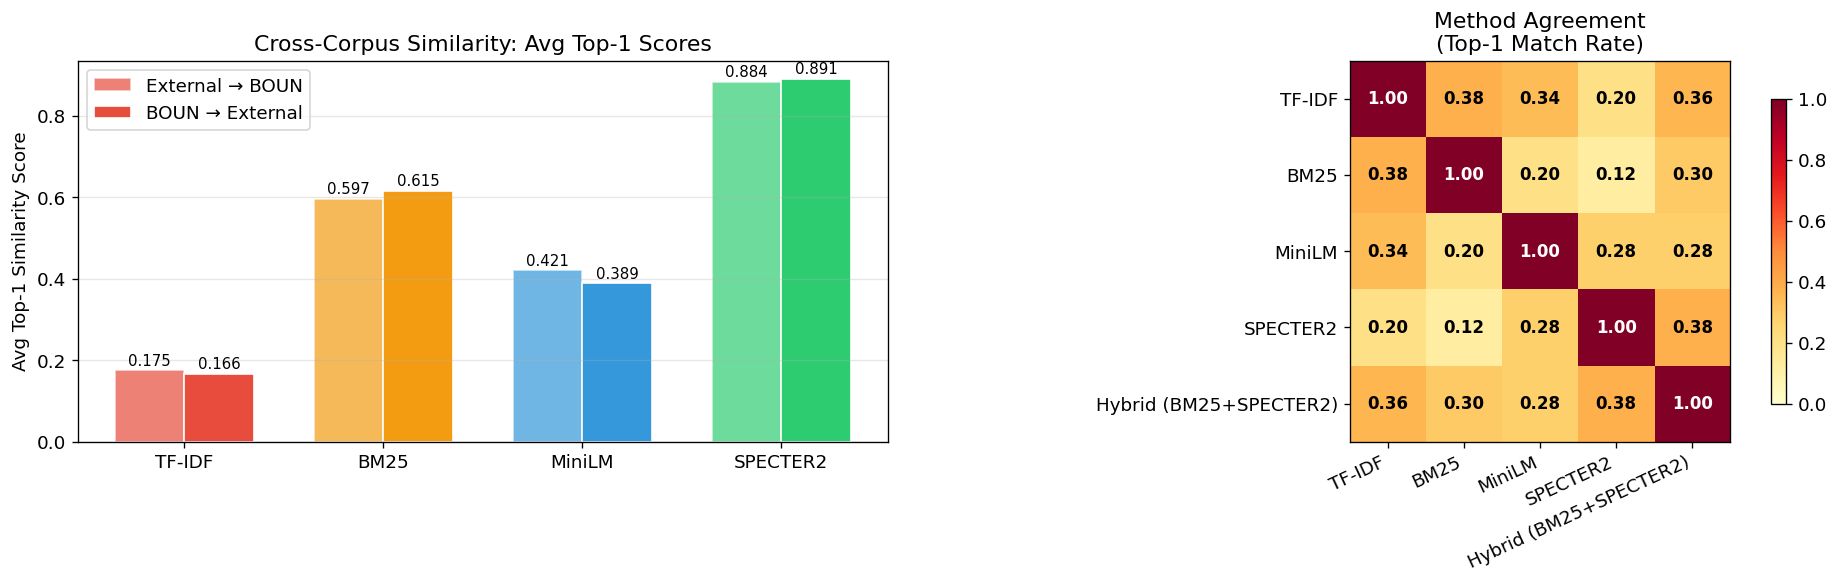

Saved: eval_dataset/cross_corpus_analysis.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Plot: Cross-corpus avg similarity scores (Task 1a & 1b) ---
ax = axes[0]
# Only show methods with comparable scores (exclude hybrid which uses RRF scores)
score_methods = [m for m in METHODS if m != 'hybrid']
x = np.arange(len(score_methods))
width = 0.35

avg_1a = []
avg_1b = []
for method in score_methods:
    scores_1a = [results_1a[method][i][0][1] for i in range(len(results_1a[method]))]
    scores_1b = [results_1b[method][i][0][1] for i in range(len(results_1b[method]))]
    avg_1a.append(np.mean(scores_1a))
    avg_1b.append(np.mean(scores_1b))

bars1 = ax.bar(x - width/2, avg_1a, width, label='External → BOUN',
               color=[colors[m] for m in score_methods], alpha=0.7, edgecolor='white')
bars2 = ax.bar(x + width/2, avg_1b, width, label='BOUN → External',
               color=[colors[m] for m in score_methods], alpha=1.0, edgecolor='white')

for bar, val in zip(bars1, avg_1a):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, avg_1b):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Avg Top-1 Similarity Score')
ax.set_title('Cross-Corpus Similarity: Avg Top-1 Scores')
ax.set_xticks(x)
ax.set_xticklabels([method_labels[m] for m in score_methods])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# --- Plot: Method agreement heatmap (Task 1a) ---
ax = axes[1]
n_queries = len(results_1a[METHODS[0]])
agreement = np.zeros((len(METHODS), len(METHODS)))
for i in range(len(METHODS)):
    for j in range(len(METHODS)):
        agree = sum(1 for q in range(n_queries)
                    if results_1a[METHODS[i]][q][0][0] == results_1a[METHODS[j]][q][0][0])
        agreement[i, j] = agree / n_queries

im = ax.imshow(agreement, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(METHODS)))
ax.set_yticks(range(len(METHODS)))
ax.set_xticklabels([method_labels[m] for m in METHODS], rotation=25, ha='right')
ax.set_yticklabels([method_labels[m] for m in METHODS])
ax.set_title('Method Agreement\n(Top-1 Match Rate)')
for i in range(len(METHODS)):
    for j in range(len(METHODS)):
        ax.text(j, i, f'{agreement[i,j]:.2f}', ha='center', va='center',
                fontweight='bold', fontsize=10,
                color='white' if agreement[i,j] > 0.5 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('eval_dataset/cross_corpus_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eval_dataset/cross_corpus_analysis.png")

## Task 3 — Intra-Paper Similarity

These tasks validate that the similarity pipeline ranks known-relevant papers highly.

**3a. Same-Author Paper Ranking** — Given a target paper, retrieve all other papers by the same author(s) from the BOUN corpus. Rank by similarity. Expected: thematically related works by the same author should rank near the top.


Same-Author in Top-5: Bir target paper için similarity sıralaması yapıldığında, en benzer 5 paper içinde kaç tanesi aynı yazara ait? Ör: Bir yazarın 15 paper'ı var. Birini target seçiyoruz, geri kalan 14'ünü + 50 rastgele paper'ı corpus'a koyuyoruz. Similarity ile sıralıyoruz. Top-5'te aynı yazarın kaç paper'ı çıktı?

3/5 → top-5'te 3'ü aynı yazar, iyi sonuç
0/5 → hiçbiri çıkmamış, embedding o yazar için ayırt edici değil

**3b. Cited Paper Ranking** — Given a target paper, retrieve its reference list (papers it cites) from the dataset. Rank by similarity. Expected: directly cited works should score higher than unrelated papers.

In [19]:
# --- Build author & reference lookups on the FULL boun corpus ---
boun_full = boun_df_full.copy()

# Author → paper indices
author_to_papers = defaultdict(list)
paper_authors = {}

for i, row in boun_full.iterrows():
    auths = row.get('authorships', [])
    if isinstance(auths, list):
        aids = []
        for a in auths:
            if isinstance(a, dict) and 'author' in a:
                aid = a['author'].get('id', '')
                if aid:
                    aids.append(aid)
                    author_to_papers[aid].append(i)
        paper_authors[i] = aids

# Paper ID → index
boun_full_id_to_idx = {str(row['id']): i for i, row in boun_full.iterrows()}

# Referenced works per paper (only those in BOUN corpus)
boun_id_set = set(boun_full_id_to_idx.keys())
paper_refs_in_corpus = {}
for i, row in boun_full.iterrows():
    refs = row.get('referenced_works', [])
    if isinstance(refs, list):
        in_corpus = [r for r in refs if str(r) in boun_id_set]
        if in_corpus:
            paper_refs_in_corpus[i] = in_corpus

# Prolific authors (≥10 papers) for Task 3a
prolific_authors = {a: idxs for a, idxs in author_to_papers.items() if len(idxs) >= 10}

# Papers with ≥3 cited works in corpus for Task 3b
papers_with_refs = {i: refs for i, refs in paper_refs_in_corpus.items() if len(refs) >= 3}

print(f"Full BOUN corpus: {len(boun_full)} papers")
print(f"Prolific authors (≥10 papers): {len(prolific_authors)}")
print(f"Papers with ≥3 in-corpus references: {len(papers_with_refs)}")

Full BOUN corpus: 3000 papers
Prolific authors (≥10 papers): 231
Papers with ≥3 in-corpus references: 85


In [20]:
# --- Task 3a: Same-Author Paper Ranking ---
TASK3_METHODS = ['tfidf', 'bm25', 'minilm']  # exclude 'specter2' - hybrid (too slow for per-query eval)
cache_3a = os.path.join(CACHE_DIR, "results_3a_all.pkl")

if os.path.exists(cache_3a):
    print(f"Loading cached Task 3a results from {cache_3a}")
    with open(cache_3a, 'rb') as f:
        task3a_results = pickle.load(f)
    missing = [m for m in TASK3_METHODS if m not in task3a_results]
    if missing:
        print(f"  Computing missing methods: {missing}")
        np.random.seed(42)
        sampled_authors = np.random.choice(list(prolific_authors.keys()), size=min(20, len(prolific_authors)), replace=False)
        for method in missing:
            print(f"\n  ▶ Task 3a with {method_labels[method]}...")
            method_results = []
            for author_id in sampled_authors:
                paper_idxs = author_to_papers[author_id]
                target_idx = np.random.choice(paper_idxs)
                same_author_idxs = [j for j in paper_idxs if j != target_idx]
                non_author_pool = [j for j in range(len(boun_full)) if j not in set(paper_idxs)]
                n_negative = min(50, len(non_author_pool))
                negative_idxs = list(np.random.choice(non_author_pool, size=n_negative, replace=False))
                corpus_idxs = same_author_idxs + negative_idxs
                is_same_author = [True] * len(same_author_idxs) + [False] * len(negative_idxs)
                target_text = boun_full.iloc[target_idx]['text']
                corpus_texts = [boun_full.iloc[j]['text'] for j in corpus_idxs]
                if method == 'tfidf':
                    sim = tfidf_similarity([target_text], corpus_texts)[0]
                elif method == 'bm25':
                    sim = bm25_similarity([target_text], corpus_texts)[0]
                else:
                    sim = sentence_embedding_similarity([target_text], corpus_texts, model_name=MODEL_MAP[method])[0]
                ranked = sorted(zip(corpus_idxs, is_same_author, sim), key=lambda x: -x[2])
                author_name = ""
                auths = boun_full.iloc[target_idx].get('authorships', [])
                for a in (auths if isinstance(auths, list) else []):
                    if isinstance(a, dict) and a.get('author', {}).get('id') == author_id:
                        author_name = a['author'].get('display_name', '')
                        break
                method_results.append({
                    'author_id': author_id, 'author_name': author_name,
                    'target_idx': target_idx, 'target_title': str(boun_full.iloc[target_idx]['title']),
                    'n_same_author': len(same_author_idxs), 'n_corpus': len(corpus_idxs),
                    'ranked': [(idx, sa, float(s)) for idx, sa, s in ranked]
                })
            task3a_results[method] = method_results
            print(f"    Done: {len(method_results)} queries")
        with open(cache_3a, 'wb') as f:
            pickle.dump(task3a_results, f)
        print(f"  Updated cache")
else:
    np.random.seed(42)
    sampled_authors = np.random.choice(list(prolific_authors.keys()), size=min(20, len(prolific_authors)), replace=False)

    task3a_results = {}
    for method in TASK3_METHODS:
        print(f"\n▶ Task 3a with {method_labels[method]}...")
        method_results = []
        for author_id in sampled_authors:
            paper_idxs = author_to_papers[author_id]
            target_idx = np.random.choice(paper_idxs)
            same_author_idxs = [j for j in paper_idxs if j != target_idx]

            non_author_pool = [j for j in range(len(boun_full)) if j not in set(paper_idxs)]
            n_negative = min(50, len(non_author_pool))
            negative_idxs = list(np.random.choice(non_author_pool, size=n_negative, replace=False))
            corpus_idxs = same_author_idxs + negative_idxs
            is_same_author = [True] * len(same_author_idxs) + [False] * len(negative_idxs)

            target_text = boun_full.iloc[target_idx]['text']
            corpus_texts = [boun_full.iloc[j]['text'] for j in corpus_idxs]

            if method == 'tfidf':
                sim = tfidf_similarity([target_text], corpus_texts)[0]
            elif method == 'bm25':
                sim = bm25_similarity([target_text], corpus_texts)[0]
            else:
                sim = sentence_embedding_similarity([target_text], corpus_texts, model_name=MODEL_MAP[method])[0]

            ranked = sorted(zip(corpus_idxs, is_same_author, sim), key=lambda x: -x[2])

            author_name = ""
            auths = boun_full.iloc[target_idx].get('authorships', [])
            for a in (auths if isinstance(auths, list) else []):
                if isinstance(a, dict) and a.get('author', {}).get('id') == author_id:
                    author_name = a['author'].get('display_name', '')
                    break

            method_results.append({
                'author_id': author_id,
                'author_name': author_name,
                'target_idx': target_idx,
                'target_title': str(boun_full.iloc[target_idx]['title']),
                'n_same_author': len(same_author_idxs),
                'n_corpus': len(corpus_idxs),
                'ranked': [(idx, sa, float(s)) for idx, sa, s in ranked]
            })
        task3a_results[method] = method_results
        print(f"  Done: {len(method_results)} queries")

    with open(cache_3a, 'wb') as f:
        pickle.dump(task3a_results, f)
    print(f"\nSaved Task 3a results to {cache_3a}")

# Summary table per method
print(f"\n{'Method':<20} {'Avg Same-Author Rank':>22} {'Same-Author in Top-5':>22}")
print("─" * 70)
for method in TASK3_METHODS:
    avg_ranks = []
    top5_hits = []
    for res in task3a_results[method]:
        sa_ranks = [r + 1 for r, (_, sa, _) in enumerate(res['ranked']) if sa]
        avg_ranks.append(np.mean(sa_ranks) if sa_ranks else res['n_corpus'])
        top5_hits.append(sum(1 for _, sa, _ in res['ranked'][:5] if sa))
    print(f"{method_labels[method]:<20} {np.mean(avg_ranks):>22.1f} {np.mean(top5_hits):>22.2f}")

Loading cached Task 3a results from data/results_cache/results_3a_all.pkl
  Computing missing methods: ['bm25']

  ▶ Task 3a with BM25...


    Done: 20 queries
  Updated cache

Method                 Avg Same-Author Rank   Same-Author in Top-5
──────────────────────────────────────────────────────────────────────
TF-IDF                                 13.9                   4.70
BM25                                   15.5                   4.80
MiniLM                                 13.1                   4.90


In [21]:
# --- Task 3b: Cited Paper Ranking ---
cache_3b = os.path.join(CACHE_DIR, "results_3b_all.pkl")

if os.path.exists(cache_3b):
    print(f"Loading cached Task 3b results from {cache_3b}")
    with open(cache_3b, 'rb') as f:
        task3b_results = pickle.load(f)
    missing = [m for m in TASK3_METHODS if m not in task3b_results]
    if missing:
        print(f"  Computing missing methods: {missing}")
        np.random.seed(42)
        sampled_papers = np.random.choice(list(papers_with_refs.keys()), size=min(20, len(papers_with_refs)), replace=False)
        for method in missing:
            print(f"\n  ▶ Task 3b with {method_labels[method]}...")
            method_results = []
            for target_idx in sampled_papers:
                ref_ids = papers_with_refs[target_idx]
                cited_idxs = [boun_full_id_to_idx[str(rid)] for rid in ref_ids if str(rid) in boun_full_id_to_idx]
                cited_set = set(cited_idxs)
                non_cited_pool = [j for j in range(len(boun_full)) if j != target_idx and j not in cited_set]
                n_negative = min(50, len(non_cited_pool))
                negative_idxs = list(np.random.choice(non_cited_pool, size=n_negative, replace=False))
                corpus_idxs = cited_idxs + negative_idxs
                is_cited = [True] * len(cited_idxs) + [False] * len(negative_idxs)
                target_text = boun_full.iloc[target_idx]['text']
                corpus_texts = [boun_full.iloc[j]['text'] for j in corpus_idxs]
                if method == 'tfidf':
                    sim = tfidf_similarity([target_text], corpus_texts)[0]
                elif method == 'bm25':
                    sim = bm25_similarity([target_text], corpus_texts)[0]
                else:
                    sim = sentence_embedding_similarity([target_text], corpus_texts, model_name=MODEL_MAP[method])[0]
                ranked = sorted(zip(corpus_idxs, is_cited, sim), key=lambda x: -x[2])
                method_results.append({
                    'target_idx': target_idx, 'target_title': str(boun_full.iloc[target_idx]['title']),
                    'n_cited': len(cited_idxs), 'n_corpus': len(corpus_idxs),
                    'ranked': [(idx, ic, float(s)) for idx, ic, s in ranked]
                })
            task3b_results[method] = method_results
            print(f"    Done: {len(method_results)} queries")
        with open(cache_3b, 'wb') as f:
            pickle.dump(task3b_results, f)
        print(f"  Updated cache")
else:
    np.random.seed(42)
    sampled_papers = np.random.choice(list(papers_with_refs.keys()), size=min(20, len(papers_with_refs)), replace=False)

    task3b_results = {}
    for method in TASK3_METHODS:
        print(f"\n▶ Task 3b with {method_labels[method]}...")
        method_results = []
        for target_idx in sampled_papers:
            ref_ids = papers_with_refs[target_idx]
            cited_idxs = [boun_full_id_to_idx[str(rid)] for rid in ref_ids if str(rid) in boun_full_id_to_idx]

            cited_set = set(cited_idxs)
            non_cited_pool = [j for j in range(len(boun_full)) if j != target_idx and j not in cited_set]
            n_negative = min(50, len(non_cited_pool))
            negative_idxs = list(np.random.choice(non_cited_pool, size=n_negative, replace=False))
            corpus_idxs = cited_idxs + negative_idxs
            is_cited = [True] * len(cited_idxs) + [False] * len(negative_idxs)

            target_text = boun_full.iloc[target_idx]['text']
            corpus_texts = [boun_full.iloc[j]['text'] for j in corpus_idxs]

            if method == 'tfidf':
                sim = tfidf_similarity([target_text], corpus_texts)[0]
            elif method == 'bm25':
                sim = bm25_similarity([target_text], corpus_texts)[0]
            else:
                sim = sentence_embedding_similarity([target_text], corpus_texts, model_name=MODEL_MAP[method])[0]

            ranked = sorted(zip(corpus_idxs, is_cited, sim), key=lambda x: -x[2])

            method_results.append({
                'target_idx': target_idx,
                'target_title': str(boun_full.iloc[target_idx]['title']),
                'n_cited': len(cited_idxs),
                'n_corpus': len(corpus_idxs),
                'ranked': [(idx, ic, float(s)) for idx, ic, s in ranked]
            })
        task3b_results[method] = method_results
        print(f"  Done: {len(method_results)} queries")

    with open(cache_3b, 'wb') as f:
        pickle.dump(task3b_results, f)
    print(f"\nSaved Task 3b results to {cache_3b}")

# Summary table per method
print(f"\n{'Method':<20} {'Avg Cited Rank':>16} {'Cited in Top-5':>16}")
print("─" * 56)
for method in TASK3_METHODS:
    avg_ranks = []
    top5_hits = []
    for res in task3b_results[method]:
        cited_ranks = [r + 1 for r, (_, ic, _) in enumerate(res['ranked']) if ic]
        avg_ranks.append(np.mean(cited_ranks) if cited_ranks else res['n_corpus'])
        top5_hits.append(sum(1 for _, ic, _ in res['ranked'][:5] if ic))
    print(f"{method_labels[method]:<20} {np.mean(avg_ranks):>16.1f} {np.mean(top5_hits):>16.2f}")

Loading cached Task 3b results from data/results_cache/results_3b_all.pkl
  Computing missing methods: ['bm25']

  ▶ Task 3b with BM25...


    Done: 20 queries


  Updated cache

Method                 Avg Cited Rank   Cited in Top-5
────────────────────────────────────────────────────────
TF-IDF                            4.0             3.65
BM25                              6.7             3.45
MiniLM                            3.8             3.55


In [22]:
# --- Task 3b: Detailed per-query table ---
for method in TASK3_METHODS:
    rows = []
    for res in task3b_results[method]:
        ranked = res['ranked']
        top1_score = ranked[0][2] if ranked else None
        top1_is_cited = ranked[0][1] if ranked else None
        hits_3 = sum(1 for _, ic, _ in ranked[:3] if ic)
        hits_10 = sum(1 for _, ic, _ in ranked[:10] if ic)
        rows.append({
            'Target Paper': res['target_title'][:80],
            'Cited Papers': res['n_cited'],
            'Corpus Size': res['n_corpus'],
            'Top-1 Score': round(top1_score, 4) if top1_score is not None else None,
            'Top-1 Is Cited': top1_is_cited,
            'Hits@3': hits_3,
            'Hits@10': hits_10,
        })
    df_table = pd.DataFrame(rows)
    print(f"\n{'='*40}")
    print(f"  {method_labels[method]} — Cited Paper Retrieval")
    print(f"{'='*40}")
    display(df_table)


  TF-IDF — Cited Paper Retrieval


,Target Paper,Cited Papers,Corpus Size,Top-1 Score,Top-1 Is Cited,Hits@3,Hits@10
0,Functional polymeric coatings: thiol-maleimide ‘click’ chemistry as a powerf...,7,57,0.3395,True,3,7
1,Smart sanitary hardware for health monitoring,3,53,0.2074,True,3,3
2,pH-Responsive nanofiber buttresses as local drug delivery devices,5,55,0.2888,False,1,5
3,Dual-Functionalizable Hydrogel Coatings: Enabling Redox-Responsive Targeted ...,12,62,0.4125,True,3,9
4,Redox-responsive micellar nanoparticles using benzothiazole-disulfide termin...,3,53,0.5092,True,2,3
5,New Perspectives in Photocatalytic Water Treatment,3,53,0.2156,True,2,3
6,Search for cascade decays of charged sleptons and sneutrinos in final states...,3,53,0.1282,True,3,3
7,High-resolution <i>P</i>-wave tomography of the 1999 Izmit and Düzce earthqu...,3,53,0.4869,True,3,3
8,An Overview of the CMS High Granularity Calorimeter,3,53,0.3494,True,3,3
9,Photo‐magnetic imaging: a new functional imaging modality for more accurate ...,3,53,0.5346,True,3,3



  BM25 — Cited Paper Retrieval


,Target Paper,Cited Papers,Corpus Size,Top-1 Score,Top-1 Is Cited,Hits@3,Hits@10
0,Functional polymeric coatings: thiol-maleimide ‘click’ chemistry as a powerf...,7,57,0.6893,True,3,6
1,Smart sanitary hardware for health monitoring,3,53,0.7331,True,2,3
2,pH-Responsive nanofiber buttresses as local drug delivery devices,5,55,0.6581,False,2,3
3,Dual-Functionalizable Hydrogel Coatings: Enabling Redox-Responsive Targeted ...,12,62,0.7536,True,3,6
4,Redox-responsive micellar nanoparticles using benzothiazole-disulfide termin...,3,53,0.8426,True,3,3
5,New Perspectives in Photocatalytic Water Treatment,3,53,0.7903,True,2,3
6,Search for cascade decays of charged sleptons and sneutrinos in final states...,3,53,0.7663,True,3,3
7,High-resolution <i>P</i>-wave tomography of the 1999 Izmit and Düzce earthqu...,3,53,0.7168,True,3,3
8,An Overview of the CMS High Granularity Calorimeter,3,53,0.7103,True,3,3
9,Photo‐magnetic imaging: a new functional imaging modality for more accurate ...,3,53,0.7698,True,3,3



  MiniLM — Cited Paper Retrieval


,Target Paper,Cited Papers,Corpus Size,Top-1 Score,Top-1 Is Cited,Hits@3,Hits@10
0,Functional polymeric coatings: thiol-maleimide ‘click’ chemistry as a powerf...,7,57,0.7031,True,3,7
1,Smart sanitary hardware for health monitoring,3,53,0.6525,True,3,3
2,pH-Responsive nanofiber buttresses as local drug delivery devices,5,55,0.6022,False,2,5
3,Dual-Functionalizable Hydrogel Coatings: Enabling Redox-Responsive Targeted ...,12,62,0.6864,True,3,10
4,Redox-responsive micellar nanoparticles using benzothiazole-disulfide termin...,3,53,0.6971,True,3,3
5,New Perspectives in Photocatalytic Water Treatment,3,53,0.6003,True,3,3
6,Search for cascade decays of charged sleptons and sneutrinos in final states...,3,53,0.5797,True,3,3
7,High-resolution <i>P</i>-wave tomography of the 1999 Izmit and Düzce earthqu...,3,53,0.8178,True,1,3
8,An Overview of the CMS High Granularity Calorimeter,3,53,0.7905,True,3,3
9,Photo‐magnetic imaging: a new functional imaging modality for more accurate ...,3,53,0.8491,True,3,3


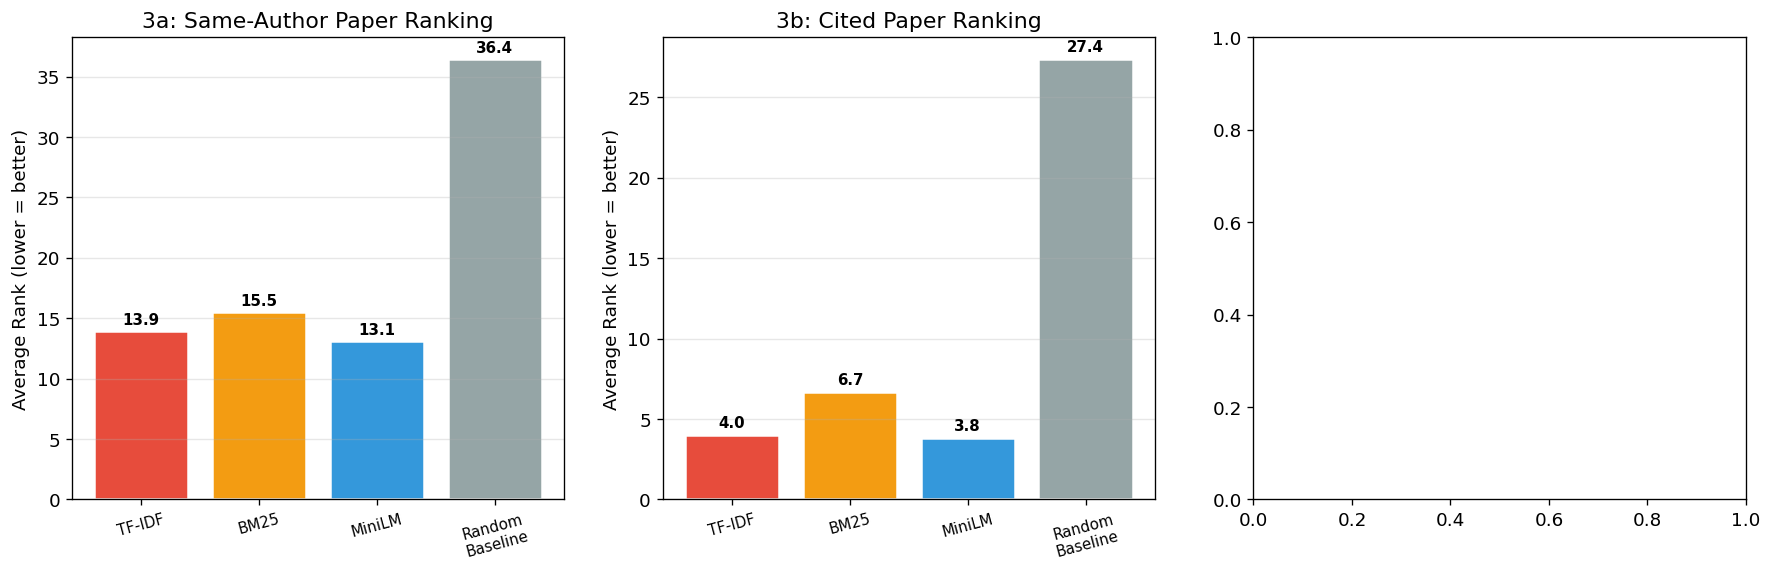

In [23]:
# --- Task 3: Visualization (ALL methods) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Same-Author avg rank per method ---
ax = axes[0]
sa_avg_ranks_per_method = {}
for method in TASK3_METHODS:
    ranks = []
    for res in task3a_results[method]:
        sa_ranks = [r + 1 for r, (_, sa, _) in enumerate(res['ranked']) if sa]
        ranks.append(np.mean(sa_ranks) if sa_ranks else res['n_corpus'])
    sa_avg_ranks_per_method[method] = np.mean(ranks)

# Add random baseline
avg_corpus = np.mean([r['n_corpus'] for r in task3a_results[TASK3_METHODS[0]]])
labels = [method_labels[m] for m in TASK3_METHODS] + ['Random\nBaseline']
heights = [sa_avg_ranks_per_method[m] for m in TASK3_METHODS] + [avg_corpus / 2]
bar_colors = [colors[m] for m in TASK3_METHODS] + ['#95a5a6']

bars = ax.bar(range(len(labels)), heights, color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9, rotation=15)
ax.set_ylabel('Average Rank (lower = better)')
ax.set_title('3a: Same-Author Paper Ranking')
for bar, val in zip(bars, heights):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# --- Plot 2: Cited Paper avg rank per method ---
ax = axes[1]
cited_avg_ranks_per_method = {}
for method in TASK3_METHODS:
    ranks = []
    for res in task3b_results[method]:
        cited_ranks = [r + 1 for r, (_, ic, _) in enumerate(res['ranked']) if ic]
        ranks.append(np.mean(cited_ranks) if cited_ranks else res['n_corpus'])
    cited_avg_ranks_per_method[method] = np.mean(ranks)

avg_corpus_3b = np.mean([r['n_corpus'] for r in task3b_results[TASK3_METHODS[0]]])
labels = [method_labels[m] for m in TASK3_METHODS] + ['Random\nBaseline']
heights = [cited_avg_ranks_per_method[m] for m in TASK3_METHODS] + [avg_corpus_3b / 2]
bar_colors = [colors[m] for m in TASK3_METHODS] + ['#95a5a6']

bars = ax.bar(range(len(labels)), heights, color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9, rotation=15)
ax.set_ylabel('Average Rank (lower = better)')
ax.set_title('3b: Cited Paper Ranking')
for bar, val in zip(bars, heights):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')


## Task 4 — Field Ablation Study

Evaluate how different text field combinations affect retrieval quality. The `build_text()` function supports a `fields` parameter — here we test which fields contribute most to performance.

**Combinations tested:**
- `title` only
- `abstract` only  
- `title + abstract`
- `title + abstract + concepts` (default)

In [24]:
# --- Task 4: Field Ablation ---
FIELD_COMBOS = [
    (('title',), 'Title only'),
    (('abstract',), 'Abstract only'),
    (('title', 'abstract'), 'Title + Abstract'),
    (('title', 'abstract', 'concepts'), 'Title + Abstract + Concepts'),
]
ABLATION_METHODS = ['tfidf', 'specter2']  # test with one sparse and one dense

cache_ablation = os.path.join(CACHE_DIR, "ablation_results.pkl")

if os.path.exists(cache_ablation):
    print(f"Loading cached ablation results from {cache_ablation}")
    with open(cache_ablation, 'rb') as f:
        ablation_results = pickle.load(f)
else:
    ablation_results = {}
    for fields, label in FIELD_COMBOS:
        print(f"\n{'='*60}")
        print(f"Fields: {label}")
        print(f"{'='*60}")
        
        # Rebuild text for full corpus with these fields
        corpus_texts_abl = [build_text(row, fields=fields) for _, row in boun_df_full.iterrows()]
        # Rebuild query texts
        bench_queries_abl = []
        for pair in benchmark_pairs:
            query = pair['query']
            parts = []
            if 'title' in fields and query.get('title'):
                parts.append(query['title'])
            if 'abstract' in fields and query.get('abstract'):
                parts.append(query['abstract'])
            bench_queries_abl.append(' '.join(parts) if parts else query.get('title', ''))
        
        for method in ABLATION_METHODS:
            print(f"  Evaluating {method_labels[method]}...")
            # We need a temporary df with correct 'id' column for evaluate_method
            result = evaluate_method(method, bench_queries_abl, bench_positive_ids,
                                     corpus_texts_abl, boun_df_full)
            ablation_results[(label, method)] = result
    
    with open(cache_ablation, 'wb') as f:
        pickle.dump(ablation_results, f)
    print(f"\nSaved ablation results to {cache_ablation}")

# Print ablation table
print(f"\n{'Fields':<30} {'Method':<12} {'MRR':>6} {'HR@5':>6} {'NDCG@5':>7} {'MAP@5':>6}")
print("─" * 72)
for fields, label in FIELD_COMBOS:
    for method in ABLATION_METHODS:
        r = ablation_results[(label, method)]
        print(f"{label:<30} {method_labels[method]:<12} {r['mrr']:>6.3f} {r['hit_rate'][5]:>6.3f} {r['ndcg'][5]:>7.3f} {r['map'][5]:>6.3f}")


Fields: Title only


  Evaluating TF-IDF...


  Evaluating SPECTER2...
  Loading cached corpus embeddings from data/embeddings_cache/allenai_specter2_base_corpus_3000_212c6103.npy
  Encoding 100 query texts...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:01<00:00,  1.19s/it]

...

  Evaluating SPECTER2...
  Loading cached corpus embeddings from data/embeddings_cache/allenai_specter2_base_corpus_3000_cf1bc745.npy
  Encoding 100 query texts...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:04<00:00,  4.33s/it]

Batches: 100%|██████████| 1/1 [00:04<00:00,  4.33s/it]


Saved ablation results to data/results_cache/ablation_results.pkl

Fields                         Method          MRR   HR@5  NDCG@5  MAP@5
────────────────────────────────────────────────────────────────────────
Title only                     TF-IDF        0.139  0.220   0.096  0.068
Title only                     SPECTER2      0.243  0.370   0.179  0.134
Abstract only                  TF-IDF        0.179  0.300   0.134  0.096
Abstract only                  SPECTER2      0.234  0.320   0.156  0.116
Title + Abstract               TF-IDF        0.202  0.360   0.152  0.106
Title + Abstract               SPECTER2      0.268  0.360   0.183  0.139
Title + Abstract + Concepts    TF-IDF        0.248  0.390   0.192  0.145
Title + Abstract + Concepts    SPECTER2      0.276  0.420   0.197  0.144


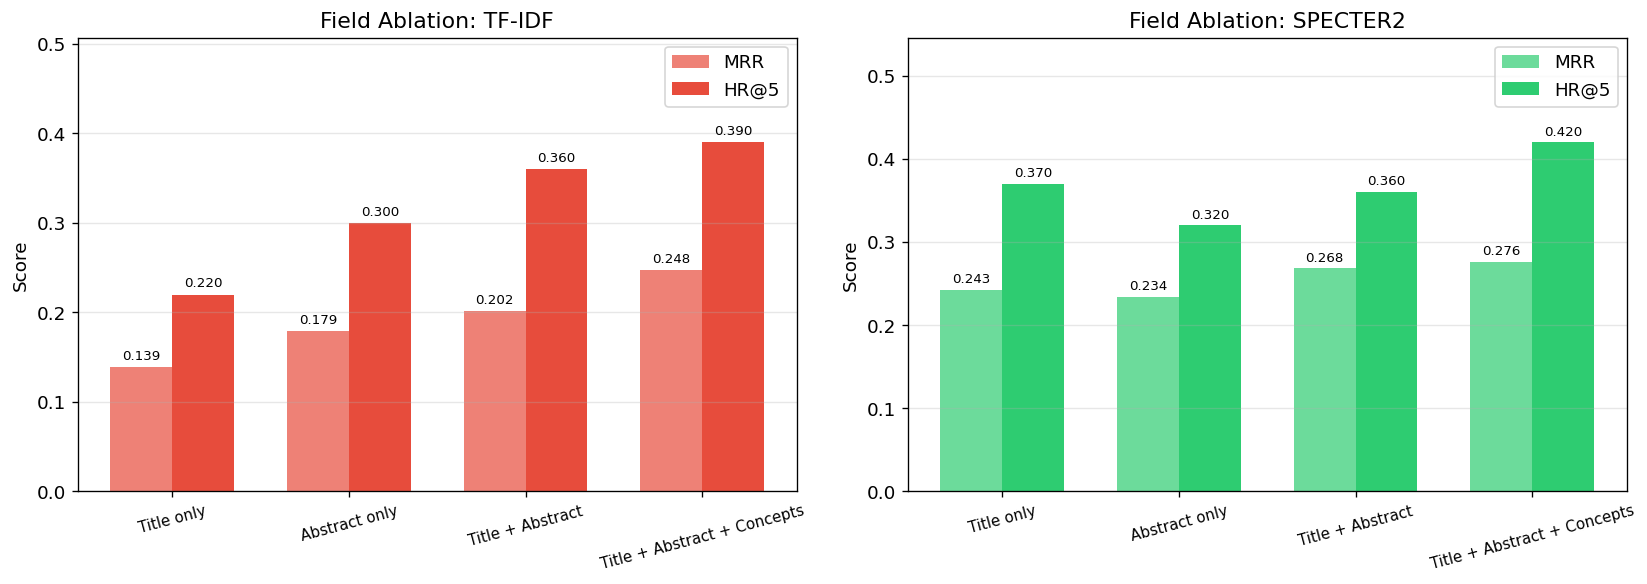

Saved: eval_dataset/field_ablation.png


In [25]:
# --- Field Ablation Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, method in enumerate(ABLATION_METHODS):
    ax = axes[ax_idx]
    field_labels = [label for _, label in FIELD_COMBOS]
    mrr_vals = [ablation_results[(label, method)]['mrr'] for _, label in FIELD_COMBOS]
    hr5_vals = [ablation_results[(label, method)]['hit_rate'][5] for _, label in FIELD_COMBOS]
    
    x = np.arange(len(field_labels))
    width = 0.35
    bars1 = ax.bar(x - width/2, mrr_vals, width, label='MRR', color=colors[method], alpha=0.7)
    bars2 = ax.bar(x + width/2, hr5_vals, width, label='HR@5', color=colors[method], alpha=1.0)
    
    for bar, val in zip(bars1, mrr_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    for bar, val in zip(bars2, hr5_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(field_labels, fontsize=9, rotation=15)
    ax.set_ylabel('Score')
    ax.set_title(f'Field Ablation: {method_labels[method]}')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(max(mrr_vals), max(hr5_vals)) * 1.3 if max(mrr_vals + hr5_vals) > 0 else 1)

plt.tight_layout()
plt.savefig('eval_dataset/field_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eval_dataset/field_ablation.png")

## Statistical Significance Testing

Use the Wilcoxon signed-rank test on per-query reciprocal ranks to determine whether differences between methods are statistically significant (p < 0.05).

Wilcoxon Signed-Rank Test (p-values on per-query MRR)
                           TF-IDF         BM25       MiniLM     SPECTER2 Hybrid (BM25+SPECTER2)
─────────────────────────────────────────────────────────────────────────────────────
              TF-IDF            — 0.1958  ns 0.0737  ns 0.7190  ns 0.2581  ns
                BM25 0.1958  ns            — 0.0049  ** 0.0854  ns 0.0040  **
              MiniLM 0.0737  ns 0.0049  **            — 0.3744  ns 0.6032  ns
            SPECTER2 0.7190  ns 0.0854  ns 0.3744  ns            — 0.4435  ns
Hybrid (BM25+SPECTER2) 0.2581  ns 0.0040  ** 0.6032  ns 0.4435  ns            —

* p < 0.05, ** p < 0.01, *** p < 0.001, ns = not significant


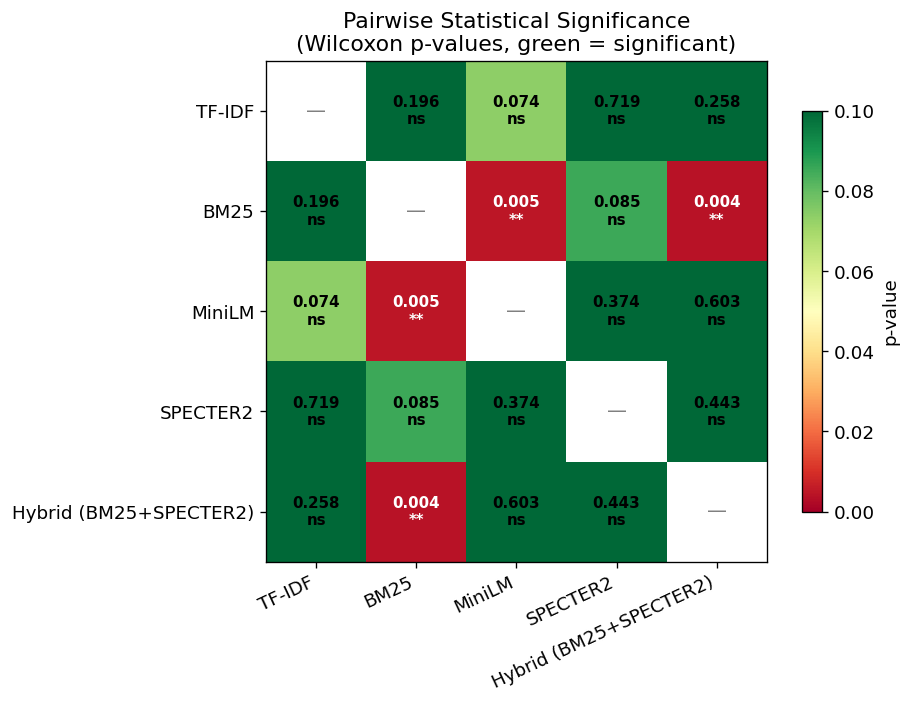

Saved: eval_dataset/statistical_significance.png


In [26]:
from scipy.stats import wilcoxon

# Build p-value matrix for method pairs
n_methods = len(METHODS)
p_values = np.ones((n_methods, n_methods))
significance = np.full((n_methods, n_methods), '', dtype=object)

for i in range(n_methods):
    for j in range(i + 1, n_methods):
        rr_i = np.array(eval_results[METHODS[i]]['reciprocal_ranks'])
        rr_j = np.array(eval_results[METHODS[j]]['reciprocal_ranks'])
        
        # Wilcoxon requires non-zero differences
        diff = rr_i - rr_j
        if np.any(diff != 0):
            stat, p = wilcoxon(rr_i, rr_j)
            p_values[i, j] = p
            p_values[j, i] = p
        else:
            p_values[i, j] = 1.0
            p_values[j, i] = 1.0
        
        sig = '***' if p_values[i, j] < 0.001 else '**' if p_values[i, j] < 0.01 else '*' if p_values[i, j] < 0.05 else 'ns'
        significance[i, j] = sig
        significance[j, i] = sig

# Print p-value table
print("Wilcoxon Signed-Rank Test (p-values on per-query MRR)")
print(f"{'':>20}", end='')
for m in METHODS:
    print(f" {method_labels[m]:>12}", end='')
print()
print("─" * (20 + 13 * n_methods))
for i, m in enumerate(METHODS):
    print(f"{method_labels[m]:>20}", end='')
    for j in range(n_methods):
        if i == j:
            print(f" {'—':>12}", end='')
        else:
            p = p_values[i, j]
            sig = significance[i, j]
            print(f" {p:.4f} {sig:>3}", end='')
    print()

print("\n* p < 0.05, ** p < 0.01, *** p < 0.001, ns = not significant")

# Visualization: p-value heatmap
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.eye(n_methods, dtype=bool)
display_p = np.ma.array(p_values, mask=mask)

im = ax.imshow(display_p, cmap='RdYlGn', vmin=0, vmax=0.1)
ax.set_xticks(range(n_methods))
ax.set_yticks(range(n_methods))
ax.set_xticklabels([method_labels[m] for m in METHODS], rotation=25, ha='right')
ax.set_yticklabels([method_labels[m] for m in METHODS])
ax.set_title('Pairwise Statistical Significance\n(Wilcoxon p-values, green = significant)')

for i in range(n_methods):
    for j in range(n_methods):
        if i != j:
            p = p_values[i, j]
            sig = significance[i, j]
            ax.text(j, i, f'{p:.3f}\n{sig}', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if p < 0.05 else 'black')
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=12, color='gray')

plt.colorbar(im, ax=ax, shrink=0.8, label='p-value')
plt.tight_layout()
plt.savefig('eval_dataset/statistical_significance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eval_dataset/statistical_significance.png")